# ***Perceptron in general:***

The Perceptron is a model that implements the following function:

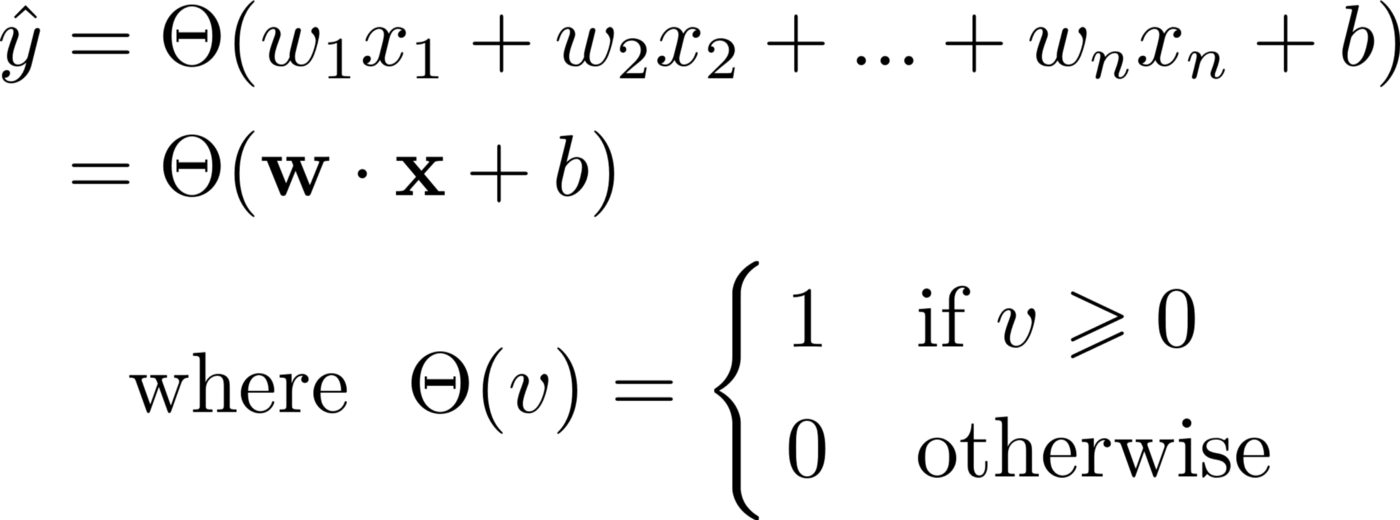

For a particular choice of the parameters w and b, the output ŷ only depends on the input vector x.

# ***Computational Graph:***

To visualize the architecture of a model, we use what is called computational graph: a directed graph which is used to represent a math function. Both variables and operations are nodes; variables are fed into operations and operations produce variables.

The computational graph of our perceptron is:

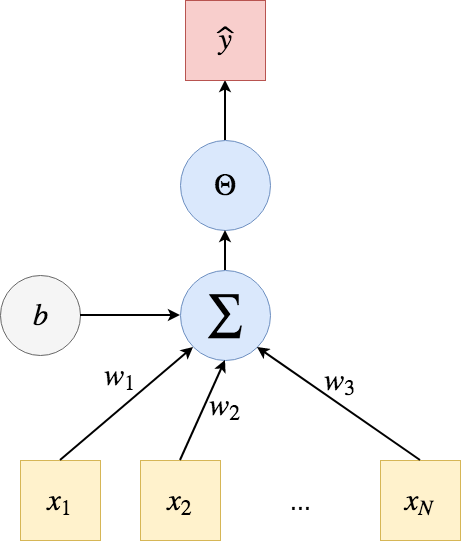

The Σ symbol represents the linear combination of the inputs x by means of the weights w and the bias b.

### ***Logical Operations:***

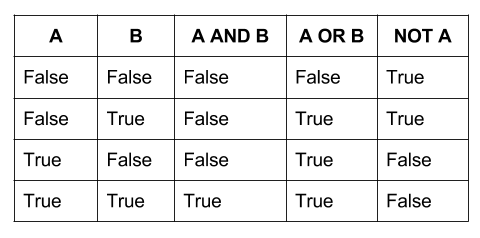

# *NOT logical function -->*

NOT(x) is a 1-variable function, that means that we will have one input at a time: N=1. Also, it is a logical function, and so both the input and the output have only two possible states: 0 and 1 (i.e., False and True): the Heaviside step function seems to fit our case since it produces a binary output.

With these considerations in mind, we can tell that, if there exists a perceptron which can implement the NOT(x) function, it would be like having two parameters, w and b, it will perform the following computation:
ŷ = ϴ(wx + b)

The fundamental question is: do exist two values that, if picked as parameters, allow the perceptron to implement the NOT logical function? When I say that a perceptron implements a function, I mean that for each input in the function’s domain the perceptron returns the same number (or vector) the function would return for the same input.
Back to our question: those values exist since we can easily find them: let’s pick w = -1 and b = 0.5.

In [ ]:
import numpy as np
#Step function:
def Step(v):
    if v >= 0:
        return 1
    else:
        return 0

#Now we need to design Perceptron model:
#Based on information we know:
def Perceptron(x, w, b):
    v = np.dot(w, x) + b
    y = Step(v)
    return y

#Now design a Not logic function based on w = -1 and b = 0.5
def NotFunction(x):
    w = -1
    b = 0.5
    return Perceptron(x, w, b)

#Now is time for testing our model:
TestCase1 = np.array(1)
TestCase2 = np.array(0)

print("NotFunction({}) = {}".format(1, NotFunction(TestCase1)))
print("NotFunction({}) = {}".format(0, NotFunction(TestCase2)))

NotFunction(1) = 0
NotFunction(0) = 1


# *AND logical function -->*

The AND logical function is a 2-variables function, AND(x1, x2), with binary inputs and output.

This graph is associated with the following computation:
ŷ = ϴ(w1*x1 + w2*x2 + b)

This time, we have three parameters: w1, w2, and b. And required values are w1 = 1, w2 = 1, b = -1.5.
(In the all following codes we use the function Percepteron that mentions before.)

In [ ]:
def AndFunction(x):
    w = np.array([1, 1])
    w.all()
    b = -1.5
    return Perceptron(x, w, b)

Testcase1 = np.array([1, 1])
Testcase2 = np.array([1, 0])
Testcase3 = np.array([0, 1])
Testcase4 = np.array([0, 0])

print("AndFunction({}, {}) = {}".format(1, 1, AndFunction(Testcase1)))
print("AndFunction({}, {}) = {}".format(1, 0, AndFunction(Testcase2)))
print("AndFunction({}, {}) = {}".format(0, 1, AndFunction(Testcase3)))
print("AndFunction({}, {}) = {}".format(0, 0, AndFunction(Testcase4)))

AndFunction(1, 1) = 1
AndFunction(1, 0) = 0
AndFunction(0, 1) = 0
AndFunction(0, 0) = 0


# *OR logical function -->*

OR(x1, x2) is a 2-variables function too, and its output is 1-dimensional (i.e., one number) and has two possible states (0 or 1). Therefore, we will use a perceptron with the same architecture as the one before. Required values are w1 = 1, w2 = 1, b = -0.5.

In [ ]:
def OrFunction(x):
    w = np.array([1, 1])
    w.all()
    b = -0.5
    return Perceptron(x, w, b)

Testcase1 = np.array([1, 1])
Testcase2 = np.array([1, 0])
Testcase3 = np.array([0, 1])
Testcase4 = np.array([0, 0])

print("OrFunction({}, {}) = {}".format(1, 1, OrFunction(Testcase1)))
print("OrFunction({}, {}) = {}".format(1, 0, OrFunction(Testcase2)))
print("OrFunction({}, {}) = {}".format(0, 1, OrFunction(Testcase3)))
print("OrFunction({}, {}) = {}".format(0, 0, OrFunction(Testcase4)))

OrFunction(1, 1) = 1
OrFunction(1, 0) = 1
OrFunction(0, 1) = 1
OrFunction(0, 0) = 0


# *XOR logical function -->*

We conclude that a single perceptron with an Heaviside activation function can implement each one of the fundamental logical functions: NOT, AND and OR.
They are called fundamental because any logical function, no matter how complex, can be obtained by a combination of those three. We can infer that, if we appropriately connect the three perceptrons we just built, we can implement any logical function!
Now XOR function is like:

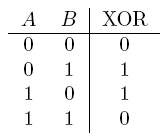

XOR function(A,B) = And(Not(And(A,B)),Or(A,B))

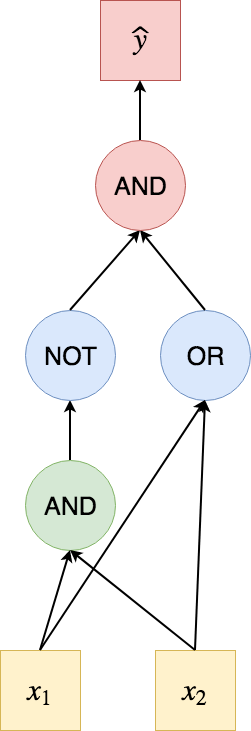

In [ ]:
def XORFunction(x):
    First = AndFunction(x)
    Second = NotFunction(First)
    Third = OrFunction(x)
    new_x = np.array([Second, Third])
    output = AndFunction(new_x)
    return output


Testcase1 = np.array([1, 1])
Testcase2 = np.array([1, 0])
Testcase3 = np.array([0, 1])
Testcase4 = np.array([0, 0])

print("XORFunction({}, {}) = {}".format(1, 1, XORFunction(Testcase1)))
print("XORFunction({}, {}) = {}".format(1, 0, XORFunction(Testcase2)))
print("XORFunction({}, {}) = {}".format(0, 1, XORFunction(Testcase3)))
print("XORFunction({}, {}) = {}".format(0, 0, XORFunction(Testcase4)))

XORFunction(1, 1) = 0
XORFunction(1, 0) = 1
XORFunction(0, 1) = 1
XORFunction(0, 0) = 0
